# Simulate single-channel open and shut intervals

In [ ]:
%matplotlib inline
import sys

In [ ]:
# Import SCALCS stuff
from samples import samples
from scalcs import scsim

### Load mechanism

In [4]:
# LOAD DEMO MECHANISM (C&H82 numerical example).
mec = samples.CH82()
mec.printout(sys.stdout)
c = 1e-6 # = 1 microMole; concentration in Moles
mec.set_eff('c', c)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16

### Simulate intervals

In [5]:
# Initialise the simulator
simulator = scsim.SCSimulator(mec)

In [7]:
 # Step 1: Simulate intervals
simulator.simulate_intervals(
        tres=50e-6, # tres = 50 microseconds; temporal resolution in seconds
        state=mec.k - 1, # initial state; unliganded closed state
        opamp=5.0, # open channel amplitude in picoAmpers
        nintmax=10000, # Number of intervals to be simulated
        seed=42)

# Step 2: Analyse intervals
simulation_result = simulator.analyse_intervals()
print("Simulation Results:")
for key, value in simulation_result.items():
    print(f"{key}: {value}")

Simulation Results:
Starting state: R
Total duration (s): 129.61890423615748
Number of intervals: 10000
Total transitions: 46027
Open intervals: 5000
Closed intervals: 5000
Mean open time (ms): 3.865822579817019
Mean closed time (ms): 22.057958267414474
Open probability: 0.14912263772781686
Open frequency (Hz): 38.574620187270796


In [9]:
# Step 3: Sample at regular intervals
sampling_info = simulator.sample_channel_trace(
    sampling_interval=20e-6,  # 20 µs sampling (50 kHz)
    duration=1,        # 1 s recording
    noise_std=1.0,      # 1 pA noise 
)
print("Sampling Results:")
for key, value in sampling_info.items():
    print(f"{key}: {value}")

Sampling Results:
Sampling frequency (Hz): 49999.99999999999
Total samples: 50000


In [10]:
# Step 4: Apply filtering
simulator.apply_filter(
    cutoff_freq=5000,    # 5 kHz filter
    order=4
)

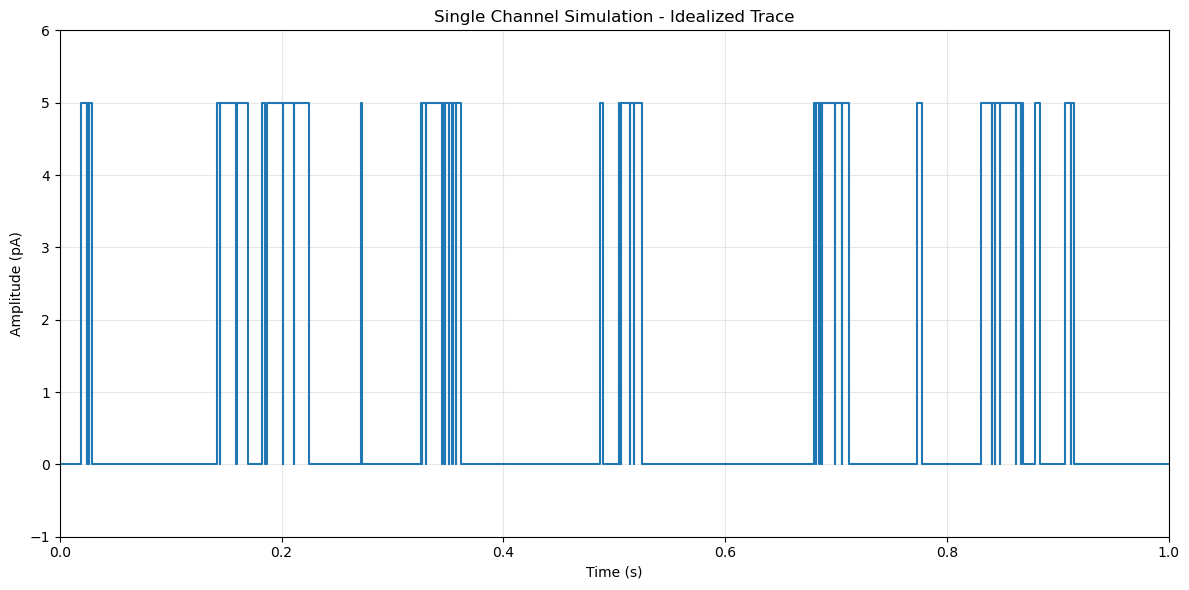

In [11]:
duration = 1 # Maximum duration to plot in seconds
simulator.plot_channel_simulation(duration) # Plot idealized trace

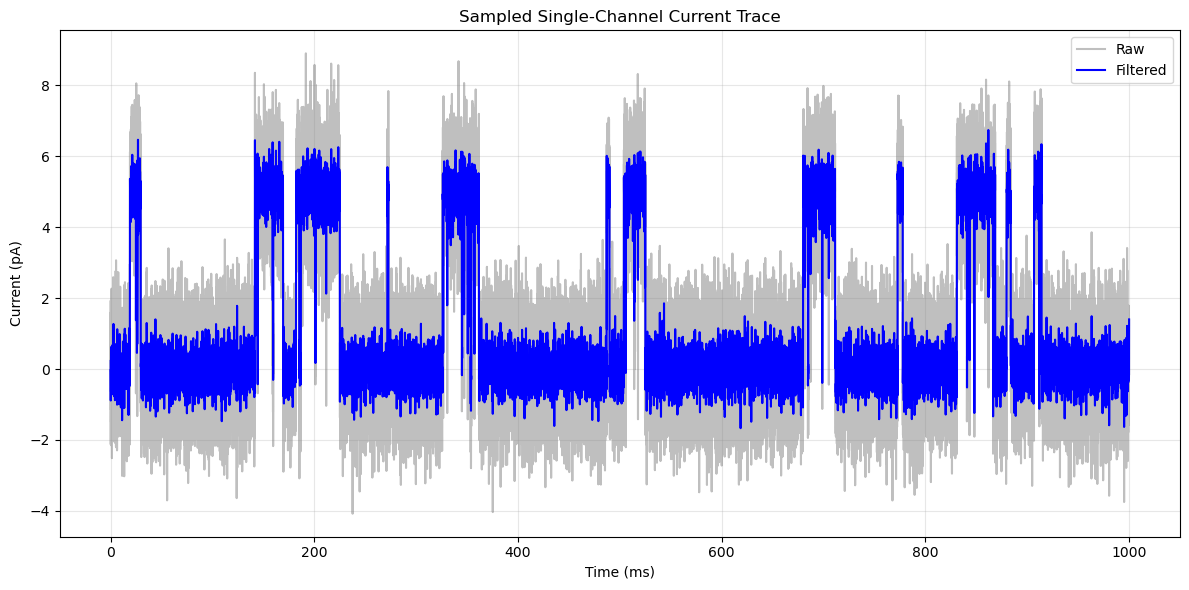

In [12]:
simulator.plot_sampled_trace() # Plot sampled trace

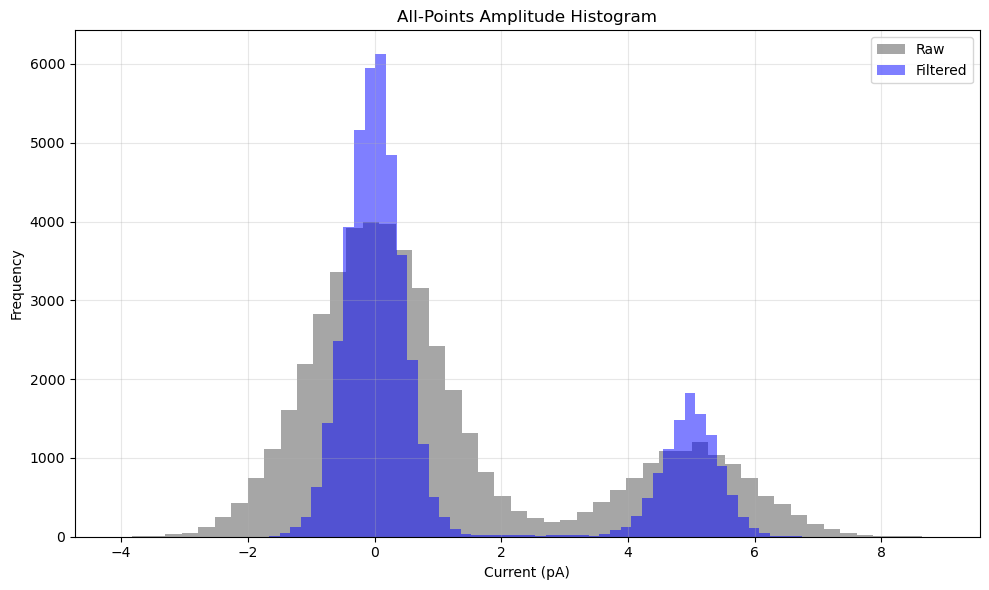

In [13]:
simulator.plot_amplitude_histogram() # Create histogram of amplitudes